TP4 RNN en NLP - Valentin MASSONNIERE - SOLO

https://github.com/TheValll/Efrei/blob/main/NLP/TP4%20-%20RNN%20pour%20le%20NLP/TP%20%204-3%20%20Appliquer%20un%20RNN%20%C3%A0%20un%20cas%20NLP%20personnalis%C3%A9/TP4%20RNN%20en%20NLP%20-%20Valentin%20MASSONNIERE.ipynb

Sélectionnez un jeu de données textuel et prétraitez les données

Mon jeu de données : https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Le fichier .csv doit se trouver dans le dossier data à la racine de ce Notebook

In [2]:
# on load le fichier csv dans un dataframe avec pandas
import pandas as pd

data = pd.read_csv("data/critics.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


On obtient une colonne des rêves des utilisateurs et une colonne sentiment qui indique si le review de l'utilisateur est positif ou négatif

On utilise la bibliothèque note afin de nettoyer la data, la tokeniser et la lemmatiser

In [3]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download("punkt_tab")
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

# tokenisation
# la fonction clean_text permet de supprimer les tags et les entités HTML et supprime tous les caractères non compris dans a-z et A-Z
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'&[a-zA-Z0-9#]+;', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

# on applique la fonction clean_text pour la colonne review puis on word_token la nouvelle colonne clean
data["clean_text"] = data["review"].apply(clean_text)
data["tokens"] = data["clean_text"].apply(word_tokenize)

# stopwords 
# on retire tous les stopwords des reviews
swords = set(stopwords.words("english"))
data["tokens_no_stop"] = data["tokens"].apply(
    lambda t: [w for w in t if w not in swords]
)

# lemmatisation
# on réduit les variations de vocabulaire avec un lemmatizer
lemmatizer = WordNetLemmatizer()
data["lemmas"] = data["tokens_no_stop"].apply(
    lambda t: [lemmatizer.lemmatize(w) for w in t]
)
data["lemmas_str"] = data["lemmas"].apply(lambda words: " ".join(words))
data.head()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,review,sentiment,clean_text,tokens,tokens_no_stop,lemmas,lemmas_str
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, oz, epis...","[one, reviewer, mentioned, watching, oz, episo...",one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[wonderful, little, production, filming, techn...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl...","[basically, theres, family, little, boy, jake,...","[basically, there, family, little, boy, jake, ...",basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,...","[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...


On obtient de nouvelles colonnes avec la data nettoyer, la tokenisation et la lemmatisation

In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# on garde les 20 000 mots les plus fréquents
MAX_VOCAB = 20000
MAX_LEN = 200

# entraînement du tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<UNK>")
tokenizer.fit_on_texts(data["lemmas_str"])

# on appelle le tokenizer pour les séquences dans lemmas_str
sequences = tokenizer.texts_to_sequences(data["lemmas_str"])

# on égalise la longueur des séquences
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

# on transforme les sentiments positifs en 1 et négatifs en 0
y = (data["sentiment"] == "positive").astype(int)

# on split le jeu de données en jeu d'entraînement et de test avec un ratio représentatif du jeu de données initial
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(y_train.value_counts()) 
print(y_test.value_counts())

sentiment
1    20000
0    20000
Name: count, dtype: int64
sentiment
0    5000
1    5000
Name: count, dtype: int64


On as, un jeu d'entraînement contenant 20 000 reviens positifs et négatifs et un jeu de test contenant 5 000 reviens positifs et négatifs

Concevez et implémentez un modèle RNN pour résoudre la tâche.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# représentation du mot par un vecteur de 128 dimensions
EMBED_DIM = 128
model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN), # couche 1
    LSTM(128, return_sequences=False), # couche 2
    Dropout(0.4), # couche 3 -> on supprime 40 % des neurones pendant l'entraînement
    Dense(64, activation='relu'), # couche 4 -> récupération des informations des LSTM
    Dropout(0.4), # couche 5 
    Dense(1, activation='sigmoid') # couche 6 -> on utilise un sigmoïde pour une conversion binaire des résultats
])
model.compile(
    loss='binary_crossentropy', # loss function pour la classification binaire
    optimizer='adam',
    metrics=['accuracy'] # on garde en mémoire l'avancement de la précision pendant l’entraînement.
)
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 200, 128)          2560000   
                                                                 
 lstm_3 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dropout_7 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 1)                 65        
                                                                 
Total params: 2699905 (10.30 MB)
Trainable params: 269

In [25]:
# entraînement du modèle
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

Epoch 1/5
500/500 [==============================] - 435s 869ms/step - loss: 0.6944 - accuracy: 0.5142 - val_loss: 0.6824 - val_accuracy: 0.5310
Epoch 2/5
500/500 [==============================] - 383s 767ms/step - loss: 0.6592 - accuracy: 0.5495 - val_loss: 0.6577 - val_accuracy: 0.5541
Epoch 3/5
500/500 [==============================] - 383s 767ms/step - loss: 0.6034 - accuracy: 0.6403 - val_loss: 0.6687 - val_accuracy: 0.5434
Epoch 4/5
500/500 [==============================] - 382s 764ms/step - loss: 0.5130 - accuracy: 0.7703 - val_loss: 0.6091 - val_accuracy: 0.7219
Epoch 5/5
500/500 [==============================] - 365s 731ms/step - loss: 0.4907 - accuracy: 0.7963 - val_loss: 0.5667 - val_accuracy: 0.7806


Évaluez la performance et discutez des résultats.

In [26]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Accuracy: {acc:.4f}")

313/313 [==============================] - 6s 20ms/step - loss: 0.5677 - accuracy: 0.7757
Accuracy: 0.7757


Test avec une phrase positive.

In [27]:
# on refait le pipeline de nettoyage et de tokenisation puis on prédit le résultat avec le modèle entraîné
text = "This movie was really cool !" 
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(result)

1/1 [==============================] - 0s 153ms/step
positive


Test avec une phrase négative.

In [29]:
# on refait le pipeline de nettoyage et de tokenisation puis on prédit le résultat avec le modèle entraîné
text = "This movie was so bad !" 
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(result)

1/1 [==============================] - 0s 14ms/step
positive


On réalise un graphique montrant les valeurs réelles et prédites par notre modèle.

313/313 [==============================] - 6s 20ms/step


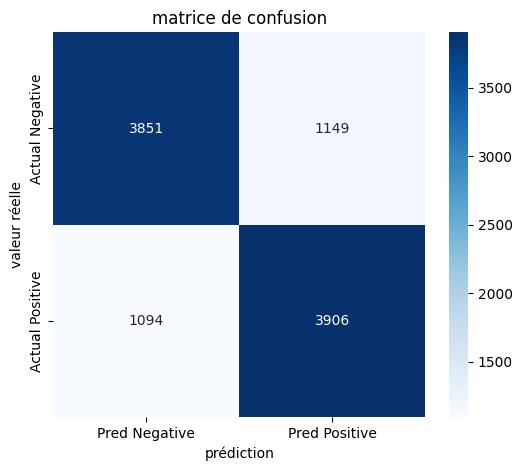

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# prob prédites par le modèle
y_pred_prob = model.predict(X_test)

# conversion en binaire
y_pred = (y_pred_prob > 0.5).astype(int)

# conversion en 1D
y_test_flat = np.array(y_test).flatten()
y_pred_flat = y_pred.flatten()

# matrice de confusion
cm = confusion_matrix(y_test_flat, y_pred_flat)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred Negative","Pred Positive"], yticklabels=["Actual Negative","Actual Positive"])
plt.xlabel("prédiction")
plt.ylabel("valeur réelle")
plt.title("matrice de confusion")
plt.show()


Les résultats et les 2 tests montrent qu'une précision de 77% ne suffit pas à classer correctement les reviews des utilisateurs. Pour améliorer ceci, nous allons expérimenter en modifiant les hyperparamètres et des des variantes LSTM. Sur la matrice de confusion, on observe que le modele fait 1 149 faux positifs et 1 094 faux negatifs. 

Pour ameliorer le modele et sa precision, je vais passer en LSTM biderectionnel afin de capturer le contexte avant et arriere.

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 200, 128)          2560000   
                                                                 
 bidirectional_1 (Bidirecti  (None, 256)               263168    
 onal)                                                           
                                                                 
 dropout_8 (Dropout)         (None, 256)               0         
                                                                 
 dense_8 (Dense)             (None, 64)                16448     
                                                                 
 dropout_9 (Dropout)         (None, 64)                0         
                                                                 
 dense_9 (Dense)             (None, 1)                 65        
                                                      

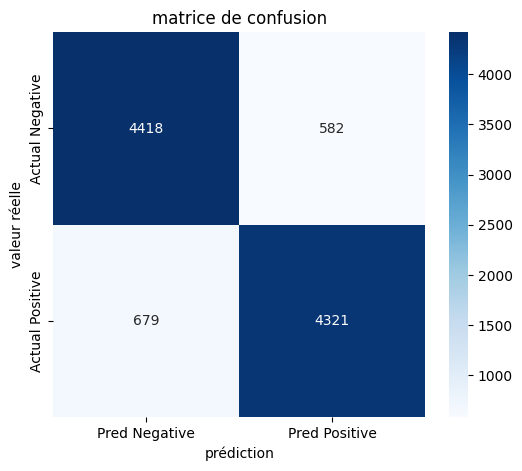

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

EMBED_DIM = 128
model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),  # couche 1
    Bidirectional(LSTM(128, return_sequences=False)),  # couche 2 modifiée en bidirectionnelle
    Dropout(0.4),  # couche 3
    Dense(64, activation='relu'),  # couche 4
    Dropout(0.4),  # couche 5
    Dense(1, activation='sigmoid')  # couche 6
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# entraînement du modèle
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

loss, acc = model.evaluate(X_test, y_test)
print(f"Accuracy: {acc:.4f}")

# prob prédites par le modèle
y_pred_prob = model.predict(X_test)

# conversion en binaire
y_pred = (y_pred_prob > 0.5).astype(int)

# conversion en 1D
y_test_flat = np.array(y_test).flatten()
y_pred_flat = y_pred.flatten()

# matrice de confusion
cm = confusion_matrix(y_test_flat, y_pred_flat)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred Negative","Pred Positive"], yticklabels=["Actual Negative","Actual Positive"])
plt.xlabel("prédiction")
plt.ylabel("valeur réelle")
plt.title("matrice de confusion")
plt.show()

Test avec des phrases positives et négatives.

In [39]:
# on refait le pipeline de nettoyage et de tokenisation puis on prédit le résultat avec le modèle entraîné
text = "I loved the movie!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I loved the movie! : {result}")

text = "This film is amazing!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"This film is amazing! : {result}")

text = "Such a great experience!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"Such a great experience! : {result}")

text = "I had a wonderful time watching this."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I had a wonderful time watching this. : {result}")

text = "This movie was awful."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"This movie was awful. : {result}")

text = "I hated the film."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I hated the film. : {result}")

text = "What a terrible experience!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"What a terrible experience! : {result}")

text = "This was a waste of time."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"This was a waste of time. : {result}")

text = "The movie had its flaws, but I really enjoyed it overall."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"The movie had its flaws, but I really enjoyed it overall. : {result}")

text = "It wasn't perfect, but I liked it."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"It wasn't perfect, but I liked it. : {result}")

text = "I didn't expect much, but it was great."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I didn't expect much, but it was great. : {result}")

text = "The movie started slow, but it got better by the end."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"The movie started slow, but it got better by the end. : {result}")

text = "It had some good parts, but overall it wasn't great."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"It had some good parts, but overall it wasn't great. : {result}")

text = "It was okay, but not as good as I thought."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"It was okay, but not as good as I thought. : {result}")

1/1 [==============================] - 0s 15ms/step
I loved the movie! : negative
1/1 [==============================] - 0s 14ms/step
This film is amazing! : negative
1/1 [==============================] - 0s 14ms/step
Such a great experience! : negative
1/1 [==============================] - 0s 13ms/step
I had a wonderful time watching this. : negative
1/1 [==============================] - 0s 13ms/step
This movie was awful. : negative
1/1 [==============================] - 0s 13ms/step
I hated the film. : negative
1/1 [==============================] - 0s 13ms/step
What a terrible experience! : negative
1/1 [==============================] - 0s 14ms/step
This was a waste of time. : negative
1/1 [==============================] - 0s 13ms/step
The movie had its flaws, but I really enjoyed it overall. : negative
1/1 [==============================] - 0s 14ms/step
It wasn't perfect, but I liked it. : negative
1/1 [==============================] - 0s 14ms/step
I didn't expect much, but i

Les résultats ici montrent que le modèle reconnaît tous types de commentaires comme étant négatifs. Ayant très peu de données pour une architecture complexe, le modèle subit un overfitting. Pour régler ce problème, il serait judicieux de réduire le nombre de neurones de 128 à 64, puis de rajouter une couche supplémentaire de régulation.

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 128)          2560000   
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 32)                4128      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0

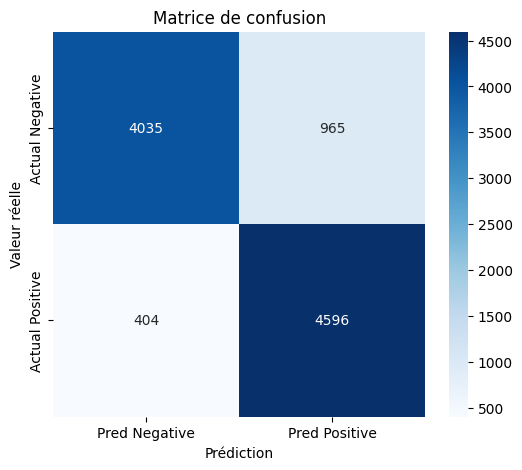

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

EMBED_DIM = 128
model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),  # couche 1
    Bidirectional(LSTM(64, return_sequences=False)),  # couche LSTM de 64 neurones
    BatchNormalization(),
    Dropout(0.3), 
    Dense(32, activation='relu'), 
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(
    loss='binary_crossentropy',  
    optimizer='adam',  
    metrics=['accuracy']  
)
model.summary() 
history = model.fit(
    X_train, y_train,
    validation_split=0.2, 
    epochs=5, 
    batch_size=64
)
loss, acc = model.evaluate(X_test, y_test)
print(f"Accuracy: {acc:.4f}")

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
y_test_flat = np.array(y_test).flatten()
y_pred_flat = y_pred.flatten()
cm = confusion_matrix(y_test_flat, y_pred_flat)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred Negative", "Pred Positive"], yticklabels=["Actual Negative", "Actual Positive"])
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion")
plt.show()

In [6]:
# on refait le pipeline de nettoyage et de tokenisation puis on prédit le résultat avec le modèle entraîné
text = "I loved the movie!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I loved the movie! : {result}")

text = "This film is amazing!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"This film is amazing! : {result}")

text = "Such a great experience!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"Such a great experience! : {result}")

text = "I had a wonderful time watching this."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I had a wonderful time watching this. : {result}")

text = "This movie was awful."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"This movie was awful. : {result}")

text = "I hated the film."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I hated the film. : {result}")

text = "What a terrible experience!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"What a terrible experience! : {result}")

text = "This was a waste of time."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"This was a waste of time. : {result}")

text = "The movie had its flaws, but I really enjoyed it overall."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"The movie had its flaws, but I really enjoyed it overall. : {result}")

text = "It wasn't perfect, but I liked it."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"It wasn't perfect, but I liked it. : {result}")

text = "I didn't expect much, but it was great."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I didn't expect much, but it was great. : {result}")

text = "The movie started slow, but it got better by the end."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"The movie started slow, but it got better by the end. : {result}")

text = "It had some good parts, but overall it wasn't great."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"It had some good parts, but overall it wasn't great. : {result}")

text = "It was okay, but not as good as I thought."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"It was okay, but not as good as I thought. : {result}")

1/1 [==============================] - 0s 16ms/step
I loved the movie! : negative
1/1 [==============================] - 0s 13ms/step
This film is amazing! : positive
1/1 [==============================] - 0s 12ms/step
Such a great experience! : negative
1/1 [==============================] - 0s 12ms/step
I had a wonderful time watching this. : negative
1/1 [==============================] - 0s 12ms/step
This movie was awful. : negative
1/1 [==============================] - 0s 12ms/step
I hated the film. : negative
1/1 [==============================] - 0s 13ms/step
What a terrible experience! : negative
1/1 [==============================] - 0s 12ms/step
This was a waste of time. : negative
1/1 [==============================] - 0s 12ms/step
The movie had its flaws, but I really enjoyed it overall. : negative
1/1 [==============================] - 0s 12ms/step
It wasn't perfect, but I liked it. : positive
1/1 [==============================] - 0s 12ms/step
I didn't expect much, but i

Ici, le modèle réagit mal. Malgré les résultats pour des phrases positives comme 'I loved the movie!' ou 'This film is amazing!', il prédit systématiquement 'negative', ce qui suppose que le modèle n'a pas bien appris à différencier les phrases positives. Je vais donc rajouter des epochs pour laisser plus de temps à l'apprentissage.

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20, 
    batch_size=64,
    callbacks=[early_stopping]
)


Epoch 1/20
500/500 [==============================] - 65s 130ms/step - loss: 0.0508 - accuracy: 0.9827 - val_loss: 0.8008 - val_accuracy: 0.8419
Epoch 2/20
500/500 [==============================] - 63s 126ms/step - loss: 0.0445 - accuracy: 0.9858 - val_loss: 0.6536 - val_accuracy: 0.8570
Epoch 3/20
500/500 [==============================] - 64s 129ms/step - loss: 0.0284 - accuracy: 0.9907 - val_loss: 0.8929 - val_accuracy: 0.8545
Epoch 4/20
500/500 [==============================] - 63s 125ms/step - loss: 0.0331 - accuracy: 0.9885 - val_loss: 0.7971 - val_accuracy: 0.8558
Epoch 5/20
500/500 [==============================] - 64s 128ms/step - loss: 0.0193 - accuracy: 0.9938 - val_loss: 0.9419 - val_accuracy: 0.8561


In [8]:
# on refait le pipeline de nettoyage et de tokenisation puis on prédit le résultat avec le modèle entraîné
text = "I loved the movie!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I loved the movie! : {result}")

text = "This film is amazing!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"This film is amazing! : {result}")

text = "Such a great experience!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"Such a great experience! : {result}")

text = "I had a wonderful time watching this."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I had a wonderful time watching this. : {result}")

text = "This movie was awful."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"This movie was awful. : {result}")

text = "I hated the film."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I hated the film. : {result}")

text = "What a terrible experience!"
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"What a terrible experience! : {result}")

text = "This was a waste of time."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"This was a waste of time. : {result}")

text = "The movie had its flaws, but I really enjoyed it overall."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"The movie had its flaws, but I really enjoyed it overall. : {result}")

text = "It wasn't perfect, but I liked it."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"It wasn't perfect, but I liked it. : {result}")

text = "I didn't expect much, but it was great."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"I didn't expect much, but it was great. : {result}")

text = "The movie started slow, but it got better by the end."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"The movie started slow, but it got better by the end. : {result}")

text = "It had some good parts, but overall it wasn't great."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"It had some good parts, but overall it wasn't great. : {result}")

text = "It was okay, but not as good as I thought."
text = clean_text(text)
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=MAX_LEN)
prob = model.predict(pad)[0][0]
result = "positive" if prob > 0.5 else "negative"
print(f"It was okay, but not as good as I thought. : {result}")

1/1 [==============================] - 0s 13ms/step
I loved the movie! : negative
1/1 [==============================] - 0s 13ms/step
This film is amazing! : positive
1/1 [==============================] - 0s 13ms/step
Such a great experience! : positive
1/1 [==============================] - 0s 11ms/step
I had a wonderful time watching this. : positive
1/1 [==============================] - 0s 14ms/step
This movie was awful. : negative
1/1 [==============================] - 0s 12ms/step
I hated the film. : negative
1/1 [==============================] - 0s 13ms/step
What a terrible experience! : negative
1/1 [==============================] - 0s 12ms/step
This was a waste of time. : negative
1/1 [==============================] - 0s 12ms/step
The movie had its flaws, but I really enjoyed it overall. : positive
1/1 [==============================] - 0s 12ms/step
It wasn't perfect, but I liked it. : positive
1/1 [==============================] - 0s 12ms/step
I didn't expect much, but i

Avec cette configuration, le modèle répond assez bien aux attentes malgré le jeu de données très faible. Il n'est pas assez grand pour couvrir beaucoup de variantes et de commentaires complexes. Pour répondre correctement à la demande, il faudrait agrandir ce jeu de données, le fusionner avec d'autres mais également jouer davantage avec les hyperparamètres pour trouver un bon ajustement.